# Day 2: Data Cleaning & EDA

**Dataset:** Titanic (from Day 1)
**Goal:** Missing value imputation, outlier detection, univariate + bivariate visualization

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)

# Load the raw data from Day 1
df = sns.load_dataset('titanic')
print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [9]:
# 1. MISSING VALUE HANDLING
print("=== Missing values before cleaning ===")
print((df.isnull().sum() / df.shape[0]) * 100)

# --- age: ~20% missing ---
# Strategy: median imputation by sex + pclass (more granular than global median)
age_median = df.groupby(['sex', 'pclass'])['age'].transform('median')
df['age'] = df['age'].fillna(age_median)

# --- embarked: 2 missing ---
# Strategy: mode (most frequent port)
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

# --- deck: 77% missing ---
# Strategy: create 'Unknown' category (dropping loses too many rows)
df['deck'] = df['deck'].cat.add_categories('Unknown').fillna('Unknown')

print("\n=== Missing values after cleaning ===")
print(df.isnull().sum())

=== Missing values before cleaning ===
survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

=== Missing values after cleaning ===
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64


In [10]:
# 2. OUTLIER DETECTION
def detect_outliers_iqr(series, multiplier=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    return (series < lower) | (series > upper), lower, upper

def detect_outliers_zscore(series, threshold=3):
    z = np.abs((series - series.mean()) / series.std())
    return z > threshold

numeric_cols = ['age', 'fare', 'sibsp', 'parch']

for col in numeric_cols:
    iqr_mask, lower, upper = detect_outliers_iqr(df[col])
    z_mask = detect_outliers_zscore(df[col])
    print(f"{col}: IQR outliers = {iqr_mask.sum()} (bounds: {lower:.2f}, {upper:.2f}), Z-score outliers = {z_mask.sum()}")

age: IQR outliers = 33 (bounds: -0.25, 57.75), Z-score outliers = 7
fare: IQR outliers = 116 (bounds: -26.72, 65.63), Z-score outliers = 20
sibsp: IQR outliers = 46 (bounds: -1.50, 2.50), Z-score outliers = 30
parch: IQR outliers = 213 (bounds: 0.00, 0.00), Z-score outliers = 15


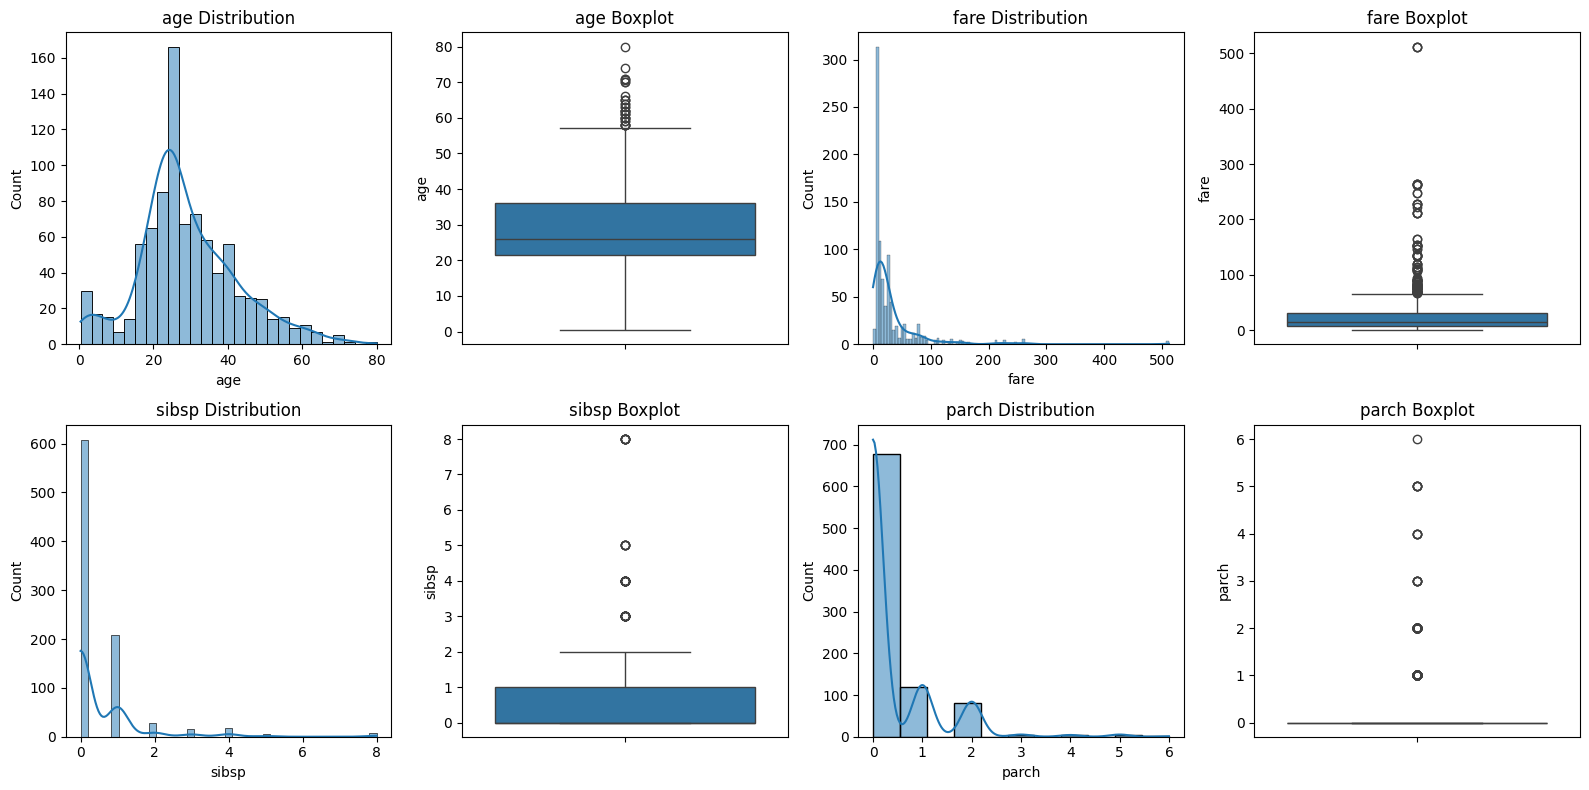

In [11]:
# 3. UNIVARIATE VISUALIZATIONS
numeric_cols = ['age', 'fare', 'sibsp', 'parch']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    # Histogram
    sns.histplot(data=df, x=col, kde=True, ax=axes[i*2])
    axes[i*2].set_title(f'{col} Distribution')
    
    # Boxplot
    sns.boxplot(data=df, y=col, ax=axes[i*2+1])
    axes[i*2+1].set_title(f'{col} Boxplot')

plt.tight_layout()
plt.show()

C:\Users\Bakrim\AppData\Local\Temp\ipykernel_1056\1533009628.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  deck_survival = df.groupby('deck')['survived'].mean().sort_values()


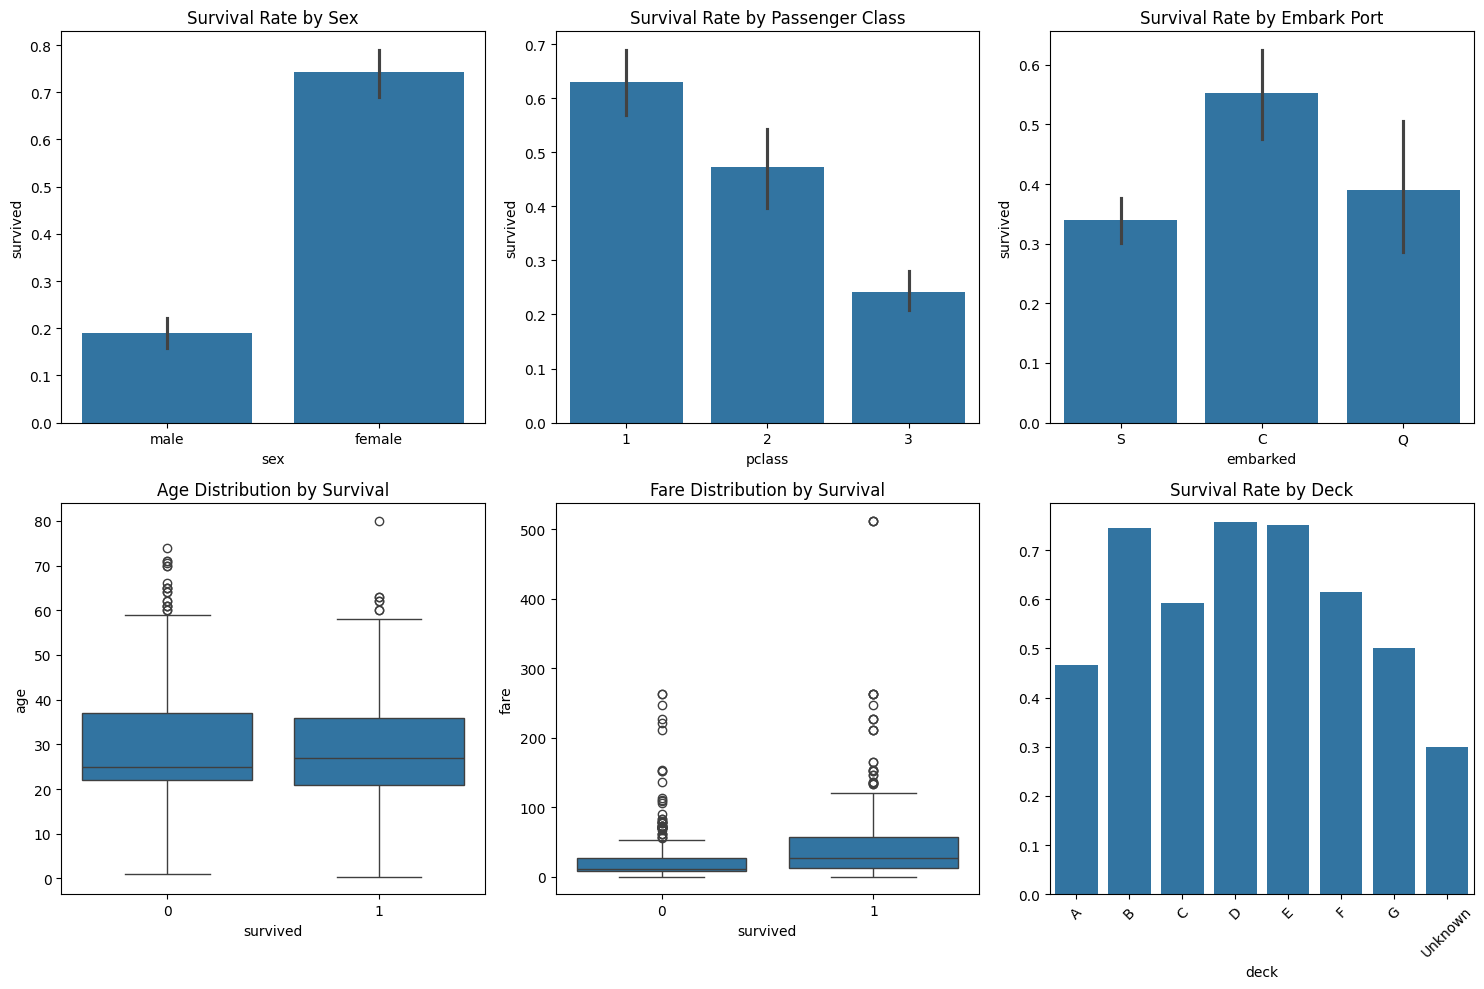

In [12]:
# 4. BIVARIATE: target vs features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# survived vs sex
sns.barplot(data=df, x='sex', y='survived', ax=axes[0])
axes[0].set_title('Survival Rate by Sex')

# survived vs pclass
sns.barplot(data=df, x='pclass', y='survived', ax=axes[1])
axes[1].set_title('Survival Rate by Passenger Class')

# survived vs embarked
sns.barplot(data=df, x='embarked', y='survived', ax=axes[2])
axes[2].set_title('Survival Rate by Embark Port')

# survived vs age (boxplot)
sns.boxplot(data=df, x='survived', y='age', ax=axes[3])
axes[3].set_title('Age Distribution by Survival')

# survived vs fare (boxplot)
sns.boxplot(data=df, x='survived', y='fare', ax=axes[4])
axes[4].set_title('Fare Distribution by Survival')

# survived vs deck
deck_survival = df.groupby('deck')['survived'].mean().sort_values()
sns.barplot(x=deck_survival.index, y=deck_survival.values, ax=axes[5])
axes[5].set_title('Survival Rate by Deck')
axes[5].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [13]:
# 5. FEATURE ENGINEERING (stretch)
# Family size
df['family_size'] = df['sibsp'] + df['parch'] + 1

# Is alone
df['is_alone'] = (df['family_size'] == 1).astype(int)

# Fare per person
df['fare_per_person'] = df['fare'] / df['family_size']

# Age bins
df['age_bin'] = pd.cut(df['age'], bins=[0, 12, 18, 35, 60, 80], labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])

print("New features created:")
print(df[['family_size', 'is_alone', 'fare_per_person', 'age_bin']].head())

New features created:
   family_size  is_alone  fare_per_person      age_bin
0            2         0          3.62500  Young Adult
1            2         0         35.64165        Adult
2            1         1          7.92500  Young Adult
3            2         0         26.55000  Young Adult
4            1         1          8.05000  Young Adult


In [16]:
# 6. SAVE CLEANED DATASET
output_path = '../data/titanic_clean.csv'
df.to_csv(output_path, index=False)
print(f"Cleaned data saved to {output_path}")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Cleaned data saved to ../data/titanic_clean.csv
Shape: (891, 19)
Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone', 'family_size', 'is_alone', 'fare_per_person', 'age_bin']


## Summary Notes

- Missing value strategy used: Median for numerical columns with outliers, more robust than mean, Mode for categorical column, and created a new category into deck column in stead of dropping it.
- Outlier handling decision: Used IQR detection and Z-score detection.
age: IQR outliers = 33, Z-score outliers = 7
fare: IQR outliers = 116, Z-score outliers = 20
sibsp: IQR outliers = 46, Z-score outliers = 30
parch: IQR outliers = 213, Z-score outliers = 15
- Key bivariate insights: Strong Correation between each of pclass, sex and deck clumns and the survival column.
- New features created: family_size, is_alone, fare_per_person, age_bin